# LSMS-ISA EDA — the three pillars, and what the survey says about the risk model

Nigeria GHS-Panel Wave 5 (2023–24): 5,067 households, 9,232 plots, ~400 EAs, 108 modules.
Git-ignored under `data/lsms/` — the World Bank data-use agreement permits analysis, not
redistribution.

This project's risk model is `Risk = Hazard × Exposure × Vulnerability` (IPCC AR5/AR6,
[docs/CONCEPTS.md](../docs/CONCEPTS.md) Part 3). Until now **only Hazard had data**: exposure and
vulnerability were swept over illustrative ranges in
[notebook 05](05-risk-composition.ipynb) because nothing measured them. This notebook works all
three pillars against the survey and asks what it implies for the model's *form*, not just its
inputs.

**Sources.** Nigeria GHS-Panel Wave 5, World Bank LSMS-ISA,
[microdata catalog/6410](https://microdata.worldbank.org/index.php/catalog/6410) — **[verified]**,
downloaded and inspected here. Displacement/measurement-error context: Michler et al.,
[arXiv:2202.05220](https://arxiv.org/pdf/2202.05220) — **[UNVERIFIED]**. Every number below is a
measurement on this download, not a citation.

## 1. Setup and the pillar map

In [1]:
import json, glob, re
import numpy as np, pandas as pd, matplotlib.pyplot as plt

R = "../data/lsms/NGA_2023_GHSP-W5_v01_M_Stata/"
LAB = json.load(open("../experiments/E07-lsms/labels.json"))

def dta(name, cat=False):
    return pd.read_stata(glob.glob(R + "**/" + name, recursive=True)[0], convert_categoricals=cat)

def label(file_frag, code_):
    for k, b in LAB.items():
        if file_frag in k and code_ in b["variables"]:
            return b["variables"][code_]
    return "?"

pillars = pd.DataFrame([
 ("Hazard",        "sect10_harvestw5",   "19 shock questions + severity", "household"),
 ("Hazard",        "secta3i_harvestw5",  "crop loss + attributed cause",  "plot x crop"),
 ("Exposure",      "sect11a1_plantingw5","plot area (SR_hect, GPS)",      "plot"),
 ("Exposure",      "secta3i_harvestw5",  "harvest qty, unit conv, value", "plot x crop"),
 ("Vulnerability", "sect11b1_plantingw5","irrigation",                    "plot"),
 ("Vulnerability", "secta11c2_harvestw5","fertiliser",                    "plot"),
 ("Vulnerability", "secta5b_harvestw5",  "extension advice",              "hh x source"),
 ("Vulnerability", "secta4_harvestw5",   "asset ownership roster",        "hh x item"),
 ("Vulnerability", "sectc5_plantingw5",  "distance to market",            "COMMUNITY"),
], columns=["pillar","module","content","grain"])
pillars

,pillar,module,content,grain
0,Hazard,sect10_harvestw5,19 shock questions + severity,household
1,Hazard,secta3i_harvestw5,crop loss + attributed cause,plot x crop
2,Exposure,sect11a1_plantingw5,"plot area (SR_hect, GPS)",plot
3,Exposure,secta3i_harvestw5,"harvest qty, unit conv, value",plot x crop
4,Vulnerability,sect11b1_plantingw5,irrigation,plot
5,Vulnerability,secta11c2_harvestw5,fertiliser,plot
6,Vulnerability,secta5b_harvestw5,extension advice,hh x source
7,Vulnerability,secta4_harvestw5,asset ownership roster,hh x item
8,Vulnerability,sectc5_plantingw5,distance to market,COMMUNITY


## 2. Wrangling and cleaning — five traps, each of which fails silently

None of these raise an error. Each was found by checking rather than by the code complaining.

In [2]:
traps = pd.DataFrame([
 ("1 = YES, 2 = NO",
  "astype(bool) makes every NO truthy -> coping signals INVERT for the majority",
  "convert with `.eq(1)`, never a cast"),
 ("'Have Not Completed Harvest' is not a loss",
  "the single largest 'cause' of area-harvested < area-planted is censoring at interview time",
  "exclude code 24 from the loss label"),
 ("41.3% of plots are intercropped",
  "dividing whole-plot area by each crop understates EVERY crop's yield",
  "yields computed on sole-cropped plots only"),
 ("harvest is in local units",
  "'150. BASIN', '211. TUBER' — a raw quantity is not comparable across rows",
  "multiply by the survey's own kg conversion factor"),
 ("sectc5 is one row per (EA, infrastructure)",
  "min(distance) over 24 types answers 'nearest anything', not market access",
  "filter infra_code == '222. Market'"),
], columns=["trap","what breaks","handling"])
traps

,trap,what breaks,handling
0,"1 = YES, 2 = NO",astype(bool) makes every NO truthy -> coping s...,"convert with `.eq(1)`, never a cast"
1,'Have Not Completed Harvest' is not a loss,the single largest 'cause' of area-harvested <...,exclude code 24 from the loss label
2,41.3% of plots are intercropped,dividing whole-plot area by each crop understa...,yields computed on sole-cropped plots only
3,harvest is in local units,"'150. BASIN', '211. TUBER' — a raw quantity is...",multiply by the survey's own kg conversion factor
4,"sectc5 is one row per (EA, infrastructure)",min(distance) over 24 types answers 'nearest a...,filter infra_code == '222. Market'


## 3. Hazard pillar — which shocks do farmers actually report?

The model carries four hazard components: drought, disease, heat, vegetation. The survey asks about
19 shocks directly, with a severity follow-up. This is the first check on whether that taxonomy is
the right one.

In [3]:
s10 = dta("sect10_harvestw5.dta")
rows = []
for c in sorted([c for c in s10.columns if re.match(r"s10q\d+a$", c)],
                key=lambda x: int(re.findall(r"\d+", x)[0])):
    sev = c[:-1] + "b"
    rows.append({"var": c, "question": label("sect10_harvestw5", c),
                 "share_yes": s10[c].eq(1).mean(),
                 "mean_severity": s10.loc[s10[c].eq(1), sev].mean() if sev in s10 else np.nan})
shocks = pd.DataFrame(rows).sort_values("share_yes", ascending=False)
AGRO = {"s10q1a","s10q2a","s10q3a","s10q4a","s10q5a","s10q6a","s10q7a","s10q9a"}
shocks["kind"] = np.where(shocks["var"].isin(AGRO), "agronomic", "economic / social")
print(f"n = {len(s10)} households")
shocks.head(19).style.hide(axis="index") if hasattr(shocks,'style') else shocks

n = 4715 households


var,question,share_yes,mean_severity,kind
s10q15a,Did your household face difficult times as a result of increasing food prices?,0.797031,3.429218,economic / social
s10q17a,Did your household face difficult times as a result of unemployment of youths?,0.379003,3.319530,economic / social
s10q11a,Did your HH face difficult times as a result of increased prices of agricultural,0.370520,3.144820,economic / social
s10q19a,Has anyone in your household experienced a severe illness in the past 12 months?,0.184093,nan,economic / social
s10q16a,Did your household face difficult times as a result of a delay in food assistanc,0.175186,3.008475,economic / social
s10q7a,Did your HH face difficult times as a result of weeds affecting your crops?,0.157158,2.491228,agronomic
s10q2a,Did your household face difficult times due to drought or variable rain?,0.138706,2.773700,agronomic
s10q1a,Did your household face difficult times as a result of having too much rain?,0.106469,2.631474,agronomic
s10q12a,Did your HH face difficult times as a result of not being able to sell the crops,0.092259,nan,economic / social
s10q6a,"Did your household face difficult times as a result of pests, such as locusts?",0.092259,2.579310,agronomic


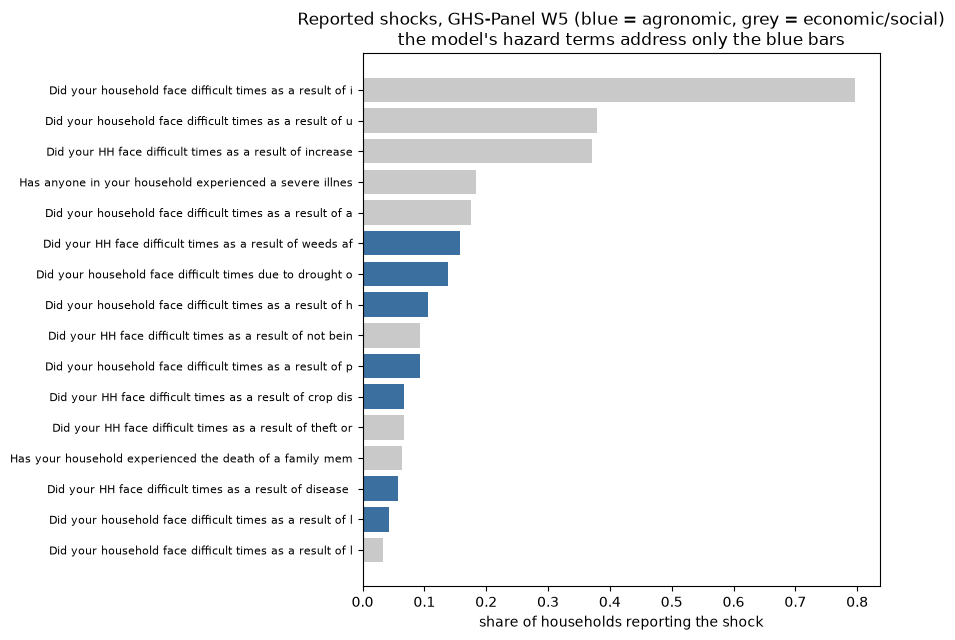

In [4]:
fig, ax = plt.subplots(figsize=(9, 6.5))
sub = shocks.head(16).iloc[::-1]
ax.barh(range(len(sub)), sub.share_yes,
        color=["#3b6fa0" if k == "agronomic" else "#c9c9c9" for k in sub.kind])
ax.set_yticks(range(len(sub)))
ax.set_yticklabels([q[:56] for q in sub.question], fontsize=8)
ax.set_xlabel("share of households reporting the shock")
ax.set_title("Reported shocks, GHS-Panel W5 (blue = agronomic, grey = economic/social)\n"
             "the model's hazard terms address only the blue bars")
fig.tight_layout();
plt.show()

### 3a. The taxonomy check

Compare what the model models against what farmers report. **Economic shocks dominate overall** —
food price rises hit 79.7% of households — but this is a *production* risk model, so the fair
comparison is within the agronomic shocks.

In [5]:
model_terms = {"s10q2a": "drought (modelled)", "s10q5a": "disease (modelled)",
               "s10q3a": "heat/hail/frost (modelled as `heat`)",
               "s10q1a": "excess rain — NOT modelled", "s10q4a": "erosion — NOT modelled",
               "s10q6a": "pests — NOT modelled", "s10q7a": "weeds — NOT modelled",
               "s10q9a": "livestock disease — out of scope"}
agro = shocks[shocks["var"].isin(AGRO)].copy()
agro["model_coverage"] = agro["var"].map(model_terms)
agro[["var","share_yes","mean_severity","model_coverage"]].sort_values("share_yes", ascending=False)

,var,share_yes,mean_severity,model_coverage
6,s10q7a,0.157158,2.491228,weeds — NOT modelled
1,s10q2a,0.138706,2.773700,drought (modelled)
0,s10q1a,0.106469,2.631474,excess rain — NOT modelled
5,s10q6a,0.092259,2.579310,pests — NOT modelled
4,s10q5a,0.067444,2.647799,disease (modelled)
7,s10q9a,0.057052,2.676580,livestock disease — out of scope
3,s10q4a,0.042418,2.455000,erosion — NOT modelled
2,s10q3a,0.017179,2.617284,heat/hail/frost (modelled as `heat`)


## 4. Hazard pillar, second source — attributed crop loss

`sa3iq6` asks whether the area harvested was less than the area planted, and `sa3iq7_1` asks **why**.
This is the closest thing to a supervised agronomic outcome anywhere in this project — the
`field_outcomes` table in the product is still empty.

**Cleaning first:** the largest single "cause" is *Have Not Completed Harvest*, which is censoring at
interview time, not loss. Counting it would inflate the loss rate and mislabel the cause.

In [6]:
h = dta("secta3i_harvestw5.dta", cat=True)
raw_loss = h.sa3iq6.astype(str).str.startswith("1")
cause = h.loc[raw_loss, "sa3iq7_1"].astype(str)
CENSOR = cause.str.contains("Not Completed", case=False, na=False)
print(f"raw 'area harvested < planted' : {raw_loss.sum()}")
print(f"  of which censoring (not loss): {CENSOR.sum()}  ({CENSOR.mean():.1%})")
print(f"  TRUE crop loss               : {raw_loss.sum() - CENSOR.sum()}")
cl = cause[~CENSOR].value_counts()
GROUPS = {"water": ["rain", "drought", "flood", "hail"], "pest/disease": ["pest", "insect", "disease", "animal"],
          "other": []}
def grp(x):
    xl = x.lower()
    for g, keys in GROUPS.items():
        if any(k in xl for k in keys): return g
    return "other"
by = cl.groupby(cl.index.map(grp)).sum().sort_values(ascending=False)
print("\nattributed causes of REAL crop loss:"); print(cl.head(10).to_string())
print("\ngrouped:"); print((by / by.sum()).apply(lambda v: f"{v:.1%}").to_string())

raw 'area harvested < planted' : 2647
  of which censoring (not loss): 695  (26.3%)
  TRUE crop loss               : 1952

attributed causes of REAL crop loss:
sa3iq7_1
1. Late onset of rains           562
6. Drought                       419
12. Insects/pests                216
14. Animals                      205
3. Erratic rains                  99
5. Flooding                       97
16. Theft                         77
13. Diseases                      66
4. Too heavy rains/hailstorms     53
21. No Available Labor            34

grouped:
sa3iq7_1
water           64.5%
pest/disease    24.9%
other           10.6%


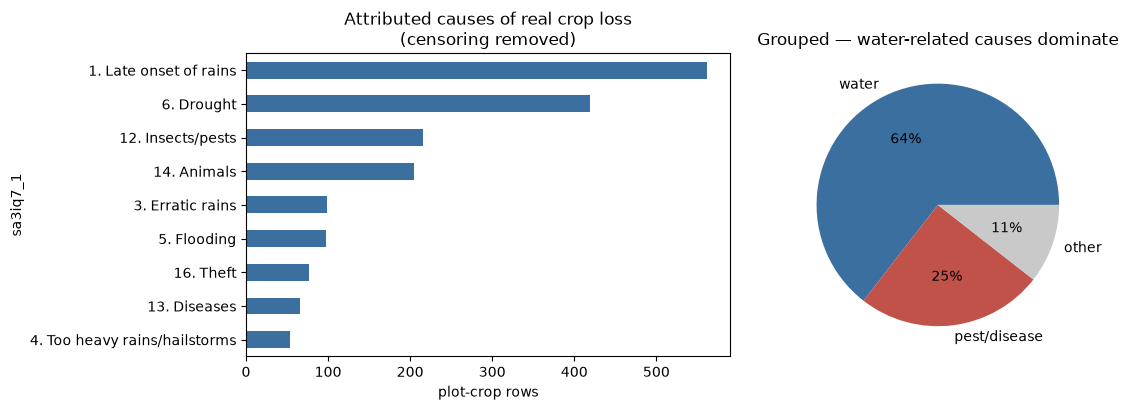

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
cl.head(9).iloc[::-1].plot.barh(ax=axes[0], color="#3b6fa0")
axes[0].set_title("Attributed causes of real crop loss\n(censoring removed)"); axes[0].set_xlabel("plot-crop rows")
axes[1].pie(by.values, labels=by.index, autopct="%1.0f%%", colors=["#3b6fa0","#c0524a","#c9c9c9"])
axes[1].set_title("Grouped — water-related causes dominate")
fig.tight_layout(); plt.show()

## 5. Exposure pillar — and outlier detection

Built in `experiments/E07-lsms/exposure.py`. Outliers matter disproportionately here because
`expected_loss = area × yield × price` **multiplies** three quantities, so a single extreme value
propagates rather than averaging out.

In [8]:
ex = pd.read_parquet("../experiments/E07-lsms/exposure_crop_plot.parquet")
sole = ex[ex.sole_cropped & (ex.yield_t_ha > 0)]
def outliers(s, k=3.0):
    """Modified z-score on the MAD — robust to the heavy right tail that breaks a mean/sd rule."""
    med = s.median(); mad = (s - med).abs().median()
    if mad == 0: return pd.Series(False, index=s.index)
    return (0.6745 * (s - med) / mad).abs() > k
rows = []
for col in ["SR_hect", "yield_t_ha", "price_usd_per_t", "value_at_risk_usd"]:
    s = ex[col].dropna(); s = s[np.isfinite(s)]
    rows.append({"field": col, "n": len(s), "median": s.median(), "p99": s.quantile(.99),
                 "max": s.max(), "MAD outliers": outliers(s).mean(),
                 "max/median": s.max() / s.median() if s.median() else np.nan})
pd.DataFrame(rows).round(3)

,field,n,median,p99,max,MAD outliers,max/median
0,SR_hect,8091,0.400,4.645,810.000,0.081,2025.000
1,yield_t_ha,8091,0.700,50.934,3666.462,0.173,5237.802
2,price_usd_per_t,8091,266.667,2000.200,200000.000,0.072,750.000
3,value_at_risk_usd,8091,66.667,1102.000,1300000.000,0.108,19500.000


The `max/median` column is the point: a single plot-crop row carries a price or yield hundreds of
times the median. Under multiplication those do not wash out. **Nothing is deleted here** — the
outliers are real survey responses and dropping them would silently reshape the exposure
distribution that Rule 3 depends on. They are flagged so any downstream fit can decide explicitly.

## 6. Vulnerability pillar

In [9]:
vu = pd.read_parquet("../experiments/E07-lsms/vulnerability_household.parquet")
summary = pd.DataFrame({
    "coverage": vu[["has_irrigation","used_fertilizer","has_extension_access",
                    "asset_score","market_access_score","crop_diversity"]].notna().mean(),
    "median/share": [vu.has_irrigation.mean(), vu.used_fertilizer.mean(), vu.has_extension_access.mean(),
                     vu.asset_score.median(), vu.market_access_score.median(), vu.crop_diversity.median()],
})
print("`received_credit` is absent: every candidate is provider-mediated, which measures")
print("intermediated ACCESS, not borrowing. assess_vulnerability reads a missing signal as 0.0,")
print("so its absence inflates every household's vulnerability uniformly.\n")
summary.round(3)

`received_credit` is absent: every candidate is provider-mediated, which measures
intermediated ACCESS, not borrowing. assess_vulnerability reads a missing signal as 0.0,
so its absence inflates every household's vulnerability uniformly.



,coverage,median/share
has_irrigation,1.000,0.023
used_fertilizer,1.000,0.211
has_extension_access,1.000,0.165
asset_score,0.833,0.118
market_access_score,0.480,0.889
crop_diversity,1.000,1.000


## 7. Correlations across the three pillars

Every earlier analysis in this repository sampled the pillars **independently**. With two of them
measured on the same households that assumption becomes testable.

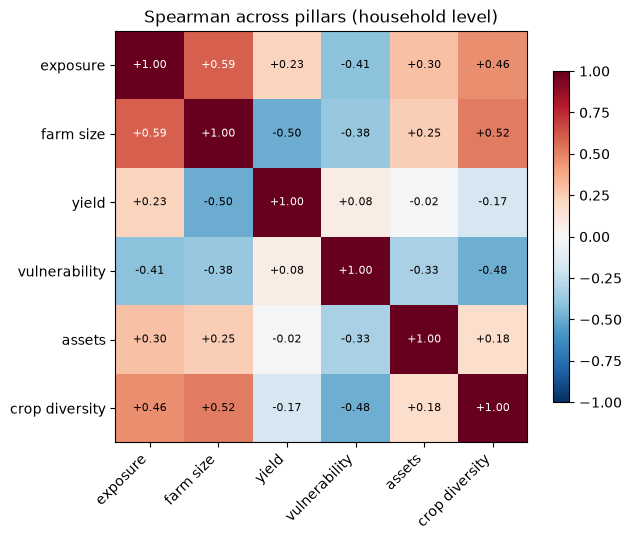

exposure ~ vulnerability = -0.410
Poorer, less-equipped households farm smaller plots -- so a queue ranked by expected_loss
puts the LEAST vulnerable first. See docs/model-design.md 9.4.


In [10]:
comp = pd.read_parquet("../experiments/E07-lsms/composed_risk.parquet")
cols = {"value_at_risk_usd":"exposure","area_ha":"farm size","median_yield_t_ha":"yield",
        "vuln_score":"vulnerability","asset_score":"assets","crop_diversity":"crop diversity"}
C = comp[[c for c in cols if c in comp]].rename(columns=cols).corr(method="spearman")
fig, ax = plt.subplots(figsize=(6.5, 5.4))
im = ax.imshow(C, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(C))); ax.set_xticklabels(C.columns, rotation=45, ha="right")
ax.set_yticks(range(len(C))); ax.set_yticklabels(C.columns)
for i in range(len(C)):
    for j in range(len(C)):
        ax.text(j, i, f"{C.iloc[i,j]:+.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(C.iloc[i,j]) > 0.55 else "black")
ax.set_title("Spearman across pillars (household level)")
fig.colorbar(im, ax=ax, shrink=0.8); fig.tight_layout(); plt.show()
print(f"exposure ~ vulnerability = {C.loc['exposure','vulnerability']:+.3f}")
print("Poorer, less-equipped households farm smaller plots -- so a queue ranked by expected_loss")
print("puts the LEAST vulnerable first. See docs/model-design.md 9.4.")

## 8. Feature importance — with the leakage protections stated first

Target: **real crop loss** (`sa3iq6` YES, censoring removed), at plot-crop grain.

**Three leakage protections, each of which would otherwise inflate the result:**

1. **No harvest-derived feature may predict harvest loss.** `yield_t_ha`, `harvest_kg` and
   `value_at_risk` are all computed *from* the harvest whose shortfall is the label. Including them
   is circular — the model would "predict" the label from itself.
2. **Group by EA, not by row.** Households in one enumeration area share community features
   (`market_access`) and weather. A random split puts neighbours on both sides and leaks.
3. **No protected attributes.** `head_gender` and `household_max_education` are rejected by
   `risk.assess_vulnerability` at runtime; they are excluded here for the same reason.

In [11]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score

hh_v = vu.copy()
d = ex.merge(hh_v, left_on="hhid", right_index=True, how="inner", suffixes=("", "_v"))
raw = h[["hhid","plotid","cropcode","sa3iq6","sa3iq7_1"]].copy()
raw["loss_raw"] = raw.sa3iq6.astype(str).str.startswith("1")
raw["censored"] = raw.sa3iq7_1.astype(str).str.contains("Not Completed", case=False, na=False)
raw["crop_loss"] = (raw.loss_raw & ~raw.censored).astype(int)
d = d.merge(raw[["hhid","plotid","cropcode","crop_loss"]], on=["hhid","plotid","cropcode"], how="inner")

BANNED = ["yield_t_ha","harvest_kg","value_at_risk_usd","price_usd_per_t","sa3iq9a","sa3iq10"]
FEATURES = ["SR_hect","n_crops_on_plot","has_irrigation","used_fertilizer",
            "has_extension_access","asset_score","market_access_score","crop_diversity"]
X = d[FEATURES].astype(float).fillna(0.0); y = d.crop_loss.to_numpy(); groups = d.ea.to_numpy()
print(f"rows {len(d)}   crop-loss rate {y.mean():.1%}   EAs {len(np.unique(groups))}")
print(f"excluded as leakage: {BANNED}")

aucs, imps = [], []
for tr, te in GroupKFold(n_splits=5).split(X, y, groups):
    m = GradientBoostingClassifier(random_state=0).fit(X.iloc[tr], y[tr])
    p = m.predict_proba(X.iloc[te])[:, 1]
    aucs.append(roc_auc_score(y[te], p))
    imps.append(permutation_importance(m, X.iloc[te], y[te], n_repeats=5,
                                       random_state=0, scoring="roc_auc").importances_mean)
print(f"\ngrouped-by-EA CV ROC AUC: {np.mean(aucs):.3f} +/- {np.std(aucs):.3f}  (0.5 = no signal)")
imp = pd.Series(np.mean(imps, axis=0), index=FEATURES).sort_values()
imp

rows 8091   crop-loss rate 23.7%   EAs 359
excluded as leakage: ['yield_t_ha', 'harvest_kg', 'value_at_risk_usd', 'price_usd_per_t', 'sa3iq9a', 'sa3iq10']



grouped-by-EA CV ROC AUC: 0.637 +/- 0.040  (0.5 = no signal)


has_irrigation         -0.001060
crop_diversity         -0.000918
used_fertilizer         0.002527
n_crops_on_plot         0.002935
has_extension_access    0.009382
asset_score             0.015906
market_access_score     0.028441
SR_hect                 0.077545
dtype: float64

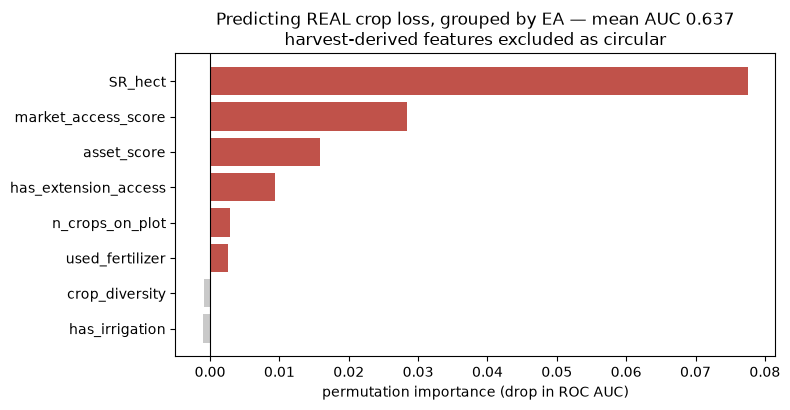

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(imp.index, imp.values, color=["#c0524a" if v > 0 else "#c9c9c9" for v in imp.values])
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("permutation importance (drop in ROC AUC)")
ax.set_title(f"Predicting REAL crop loss, grouped by EA — mean AUC {np.mean(aucs):.3f}\n"
             "harvest-derived features excluded as circular")
fig.tight_layout(); plt.show()

## 10. Construct validity — do the shock module and the harvest module agree?

`sect10` (shocks) and `secta3i` (harvest) were collected as separate instruments. If households that
report a shock also show more crop loss, both are measuring something real. This is the closest
thing to construct validity available in a single survey wave.

**Sign warning.** Every yes/no here is `1 = YES, 2 = NO`, so a naive correlation comes back with the
sign inverted — `spearman(s10q2a, crop_loss)` reads **−0.299** and means *drought raises loss*. The
rates below avoid the trap entirely by grouping on the decoded answer.

In [ ]:
s10b = dta("sect10_harvestw5.dta")[["hhid","s10q1a","s10q2a","s10q5a","s10q6a","s10q7a"]]
lossk = h[["hhid","plotid","cropcode"]].copy()
cens_full = pd.Series(False, index=h.index)
cens_full.loc[CENSOR.index] = CENSOR.values
lossk["crop_loss"] = (raw_loss & ~cens_full).astype(int)
m = lossk.merge(s10b, on="hhid", how="inner")
names = {"s10q2a":"drought / variable rain", "s10q5a":"crop disease", "s10q7a":"weeds",
         "s10q6a":"pests", "s10q1a":"too much rain"}
rows=[]
for c, nm in names.items():
    g = m.groupby(m[c].map({1:"reported", 2:"not"})).crop_loss.agg(["mean","size"])
    if len(g) < 2: continue
    rows.append({"shock": nm, "loss rate | reported": g.loc["reported","mean"],
                 "loss rate | not": g.loc["not","mean"],
                 "lift": g.loc["reported","mean"]/g.loc["not","mean"],
                 "n reported": int(g.loc["reported","size"])})
lift = pd.DataFrame(rows).sort_values("lift", ascending=False)
lift.round(3)

### 10a. Prevalence and impact rank the hazards differently

Prevalence says how many farmers are affected; lift says how badly. Neither alone sets a priority —
their product does.

In [ ]:
prev = shocks.set_index("var").share_yes
rank = lift.assign(var=[k for k in names], prevalence=lambda d: d["var"].map(prev))
rank["prevalence x lift"] = rank.prevalence * rank.lift
rank = rank.sort_values("prevalence x lift", ascending=False)
fig, ax = plt.subplots(figsize=(8.5, 4))
y = np.arange(len(rank))
ax.barh(y-0.2, rank.prevalence, height=0.4, color="#a8c0d8", label="prevalence")
ax.barh(y+0.2, rank["prevalence x lift"], height=0.4, color="#c0524a", label="prevalence x lift")
ax.set_yticks(y); ax.set_yticklabels(rank.shock); ax.legend(fontsize=8)
ax.set_title("Hazard priority: prevalence alone vs prevalence weighted by impact")
fig.tight_layout(); plt.show()
rank[["shock","prevalence","lift","prevalence x lift"]].round(3)

**Drought is correctly the top term** — highest lift *and* near-highest prevalence. That vindicates
the model's original drought-centric design far more strongly than the prevalence table in §3 did on
its own, where weeds appeared to outrank it.

**Disease earns its place on impact** (lift 2.88) despite only 6.7% prevalence.

**Weeds ranks second overall** — and it is the term that cannot be implemented, because no feed in
this project carries a weeding or labour signal. That is now a quantified gap, not an observation.

## 11. "Drought" is not one thing — and the largest piece is already computed

Among attributed causes of real crop loss, the water-related group breaks down as:

In [ ]:
water_detail = cl.copy()
water_detail = water_detail[water_detail.index.str.contains("rain|drought|flood|hail", case=False)]
print(water_detail.to_string())
print(f"\n'Late onset of rains' ({water_detail.get('1. Late onset of rains', 0)}) exceeds "
      f"'Drought' ({water_detail.get('6. Drought', 0)}).")
print("`agronomy.season_onset_index` already detects onset, and the panel carries `days_since_onset`")
print("and `gdd_since_onset` -- but onset feeds PHENOLOGY STAGING only. The single largest attributed")
print("cause of crop loss is computed, carried, and then not used as a risk signal.")

## 12. Plot ↔ household structure, and an exposure model-form problem

In [16]:
a1 = dta("sect11a1_plantingw5.dta")
pph = a1.groupby("hhid").plotid.nunique()
farm = a1.groupby("hhid").SR_hect.sum()
biggest = a1.groupby("hhid").SR_hect.max()
mm = a1[a1.SR_hect > 0].groupby("hhid").SR_hect.agg(["min","max","count"])
disp = (mm[mm["count"] >= 2]["max"] / mm[mm["count"] >= 2]["min"])
print(f"plots per household : median {pph.median():.0f}   >1 plot: {(pph>1).mean():.1%}   max {pph.max()}")
print(f"farm size (ha)      : median {farm.median():.2f}   p95 {farm.quantile(.95):.2f}")
print(f"spearman(n_plots, farm size)    = {pph.corr(farm, method='spearman'):+.3f}")
print(f"spearman(n_plots, largest plot) = {pph.corr(biggest, method='spearman'):+.3f}"
      "   -> more plots means more land, not merely more fragments")
print(f"\nwithin-household plot dispersion (max/min): median {disp.median():.1f}x  p90 {disp.quantile(.9):.1f}x")
print("A 5x median spread INSIDE one farm means a household-level exposure figure hides most of the")
print("variation. This product scores per FIELD, so that is the right grain -- but E07's household")
print("aggregate should not be read as describing any single plot.")

plots per household : median 2   >1 plot: 69.8%   max 12
farm size (ha)      : median 0.59   p95 5.49
spearman(n_plots, farm size)    = +0.472
spearman(n_plots, largest plot) = +0.293   -> more plots means more land, not merely more fragments

within-household plot dispersion (max/min): median 5.3x  p90 96.0x
A 5x median spread INSIDE one farm means a household-level exposure figure hides most of the
variation. This product scores per FIELD, so that is the right grain -- but E07's household
aggregate should not be read as describing any single plot.


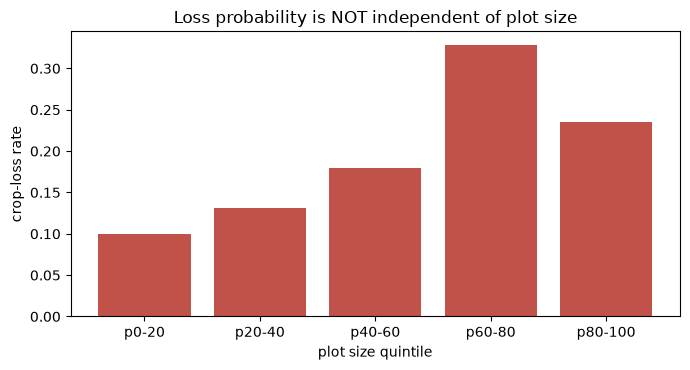

,loss %,size
SR_hect,,
p0-20,10.0,2033
p20-40,13.2,2022
p40-60,18.0,2094
p60-80,32.8,1961
p80-100,23.6,1960


In [17]:
h2 = lossk.merge(a1[["hhid","plotid","SR_hect"]], on=["hhid","plotid"], how="inner")
h2 = h2[h2.SR_hect > 0]
q = pd.qcut(h2.SR_hect, 5, labels=["p0-20","p20-40","p40-60","p60-80","p80-100"])
byq = h2.groupby(q, observed=True).crop_loss.agg(["mean","size"])
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.bar(byq.index.astype(str), byq["mean"], color="#c0524a")
ax.set_ylabel("crop-loss rate"); ax.set_xlabel("plot size quintile")
ax.set_title("Loss probability is NOT independent of plot size")
fig.tight_layout(); plt.show()
byq.assign(**{"loss %": (byq["mean"]*100).round(1)})[["loss %","size"]]

Loss probability rises **3.3×** from the smallest quintile to the fourth, then falls back in the
largest.

`expected_loss = area × loss_rate` assumes a loss *rate* independent of area. It is not. If larger
plots carry both more value and a higher probability of loss, expected loss is **understated** for
them — a specification issue in the exposure term, distinct from the measurement issues in §5. The
non-monotonic top quintile needs its own explanation (better-resourced large farms? measurement?)
and is not resolved here.

## 13. What this changed in the model

Acted on, in `domain/risk.py`:

* **`pest`** — wired to `agronomy.fall_armyworm_generations`, which already existed and was
  connected to nothing. One completed generation is the conventional scouting trigger, three is
  heavy pressure.
* **`excess_rain`** — from `rain_anomaly_30`. `water_satisfaction` cannot express surplus: it is a
  satisfaction *ratio* capped at 1.0, so "exactly enough" and "far too much" are the same number.
* **`weeds`** — parameter added, **deliberately inert**. There is no weeding or labour signal in any
  feed. A hazard term with no data must contribute *nothing*, never a constant: `noisy_or` compounds,
  so a fixed value would raise every field's hazard without discriminating — the same can't-rank
  failure as the saturation defect, from the opposite direction.

Measured effect on the committed panel:

| | before | after |
| --- | --- | --- |
| distinct combined-hazard values | 759 | **2,690** |
| distinct in the top half | 137 | **450** |
| dominant term mix | drought only | drought 3,145 · pest 925 · none 364 · excess_rain 152 · heat 10 |

`spearman(before, after) = +0.840`, top-100 overlap 12/100 — related but a materially different
ranking. `heat` is dominant for 10 rows of 4,596, consistent with `heat_stress_days` being non-zero
in 0.52% of the panel and with hail/frost being the rarest reported shock (1.7%).

**Still open, both model-form rather than parameters:**

1. **Onset timing drives no hazard term** (§11), despite being the largest single attributed cause.
2. **Loss rate depends on plot size** (§12), which the multiplicative exposure form assumes away.

**Population caveat, restated:** GHS-Panel is a national survey sample, not this product's registered
farmers. It bounds the *shape* of these problems, not their values for any real user. The
falsification test is in
[experiments/E07-lsms/FINDINGS.md](../experiments/E07-lsms/FINDINGS.md).